# Прогнозирование временных рядов: Синтетические данные, AR и ETS

Этот проект включает в себя:
1. Генерацию данных (тренд + сезонность + шум).
2. Визуализацию.
3. Обучение моделей AR и ETS.
4. Оценку качества (MAE, RMSE).

## 1. Генерация синтетических данных
На этом этапе мы создаем временной ряд, состоящий из:
* **Линейного тренда**: имитирует долгосрочный рост.
* **Сезонности**: синусоидальная волна с периодом 50 дней.
* **Гауссова шума**: случайные отклонения для приближения к реальности.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- Константы и настройки ---
RANDOM_SEED = 42
N_OBSERVATIONS = 1000
TEST_SIZE = 0.2
SEASONAL_PERIOD = 50

np.random.seed(RANDOM_SEED)
time = np.arange(N_OBSERVATIONS)

# Генерация компонентов ряда
trend = 0.05 * time
seasonality = 10 * np.sin(2 * np.pi * time / SEASONAL_PERIOD)
noise = np.random.normal(0, 2, N_OBSERVATIONS)

series = trend + seasonality + noise
df = pd.DataFrame({'value': series}, index=pd.date_range(start='2020-01-01', periods=N_OBSERVATIONS, freq='D'))

# Разделение на выборки
train_size = int(len(df) * (1 - TEST_SIZE))
train, test = df.iloc[:train_size], df.iloc[train_size:]

print(f"Конфигурация завершена. Обучающая выборка: {len(train)}, Тестовая: {len(test)}")

Конфигурация завершена. Обучающая выборка: 800, Тестовая: 200


## 2. Визуальный анализ и проверка стационарности
Перед выбором модели важно оценить визуальную структуру ряда и формально проверить его на стационарность с помощью теста Дики-Фуллера (ADF). Это определит, нужно ли применять дифференцирование.

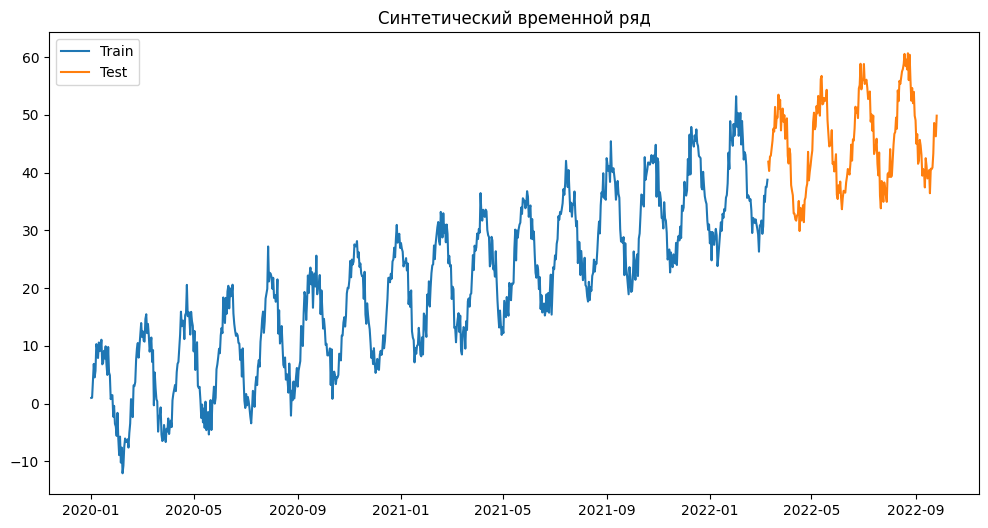

In [2]:
# 3. Визуализация данных
plt.figure(figsize=(12, 6))
plt.plot(train.index, train['value'], label='Train')
plt.plot(test.index, test['value'], label='Test')
plt.title('Синтетический временной ряд')
plt.legend()
plt.show()

In [8]:
from statsmodels.tsa.stattools import adfuller

# 3.1 Проверка стационарности (ADF Test)
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Ряд стационарен (отвергаем H0)")
    else:
        print("Ряд нестационарен (не удалось отвергнуть H0)")

check_stationarity(df['value'])

ADF Statistic: -0.8175
p-value: 0.8139
Ряд нестационарен (не удалось отвергнуть H0)


## 3. Подготовка базовой модели (Baseline)
Для оценки качества сложных алгоритмов мы создаем наивный прогноз. Наша цель — убедиться, что выбранные модели (AR, ETS) работают значительно лучше, чем простое повторение последнего известного значения.

In [9]:
# 3.2 Baseline: Наивный прогноз (значение в t = значению в t-1)
# Для теста берем последнее значение из обучающей выборки
naive_value = train['value'].iloc[-1]
naive_forecast = pd.Series([naive_value] * len(test), index=test.index)

## 4. Построение прогностических моделей
Мы используем два классических подхода:
1. **Авторегрессия (AR)**: прогнозирует будущие значения на основе зависимости от предыдущих.
2. **Экспоненциальное сглаживание (ETS)**: метод Хольта-Уинтера, который эффективно разделяет и прогнозирует тренд и сезонность.

In [5]:
# 4. Построение моделей

# Автокорреляционная модель (AR)
# Используем лаг 50, так как период синусоиды равен 50
ar_model = AutoReg(train['value'], lags=50).fit()
ar_forecast = ar_model.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Модель экспоненциального сглаживания (ETS / Holt-Winters)
ets_model = ExponentialSmoothing(train['value'], trend='add', seasonal='add', seasonal_periods=50).fit()
ets_forecast = ets_model.forecast(len(test))

# Привязываем индексы к прогнозам для визуализации
ar_forecast.index = test.index
ets_forecast.index = test.index

## 5. Оценка качества и визуализация
Сравним прогнозы моделей с реальными данными на тестовой выборке, используя метрики средней абсолютной ошибки (MAE) и среднеквадратичной ошибки (RMSE).

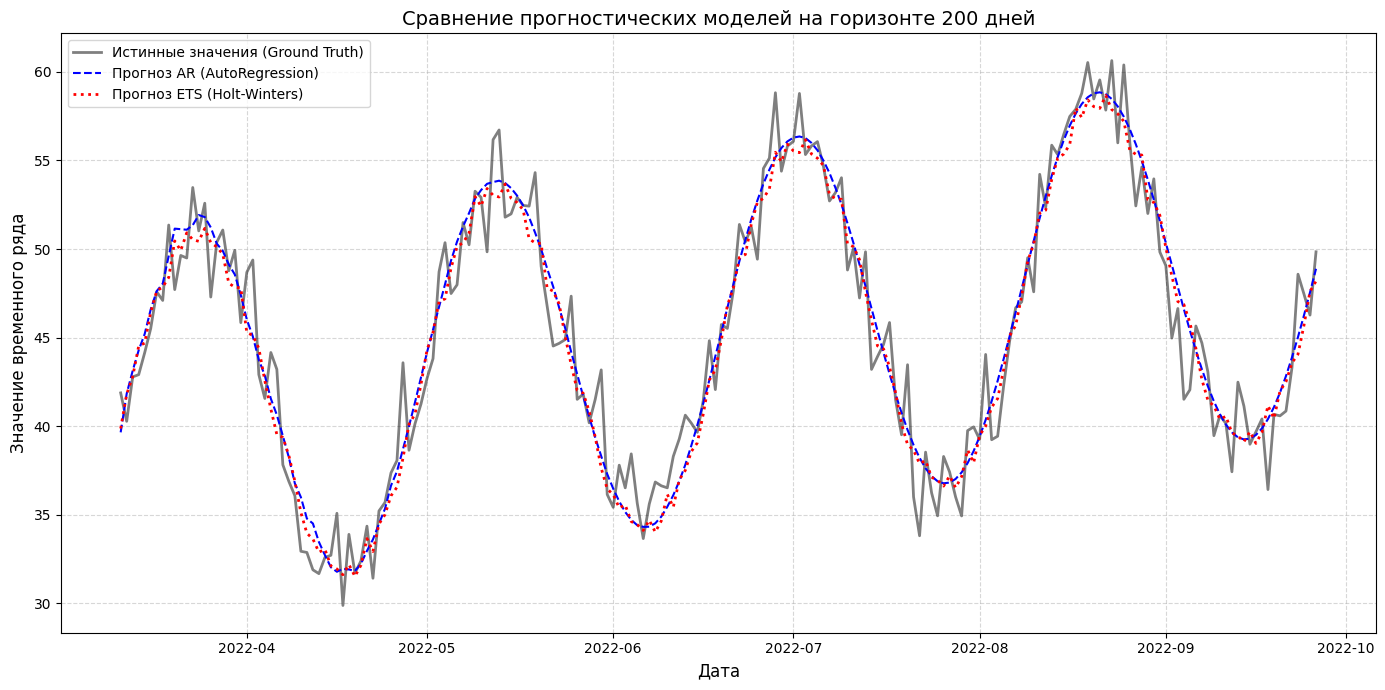

In [12]:
# Визуализация финального сравнения прогнозов
plt.figure(figsize=(14, 7))
plt.plot(test.index, test['value'], label='Истинные значения (Ground Truth)', color='black', alpha=0.5, linewidth=2)
plt.plot(ar_forecast, label='Прогноз AR (AutoRegression)', linestyle='--', color='blue')
plt.plot(ets_forecast, label='Прогноз ETS (Holt-Winters)', linestyle=':', color='red', linewidth=2)

plt.title('Сравнение прогностических моделей на горизонте 200 дней', fontsize=14)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Значение временного ряда', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Дополнительный анализ: Сравнение метрик и диагностика остатков
Проверим, насколько хорошо модели извлекли информацию из данных, проанализировав распределение ошибок.

,Metric,AR,ETS
0,MAE,1.563,1.574
1,RMSE,1.935,1.984


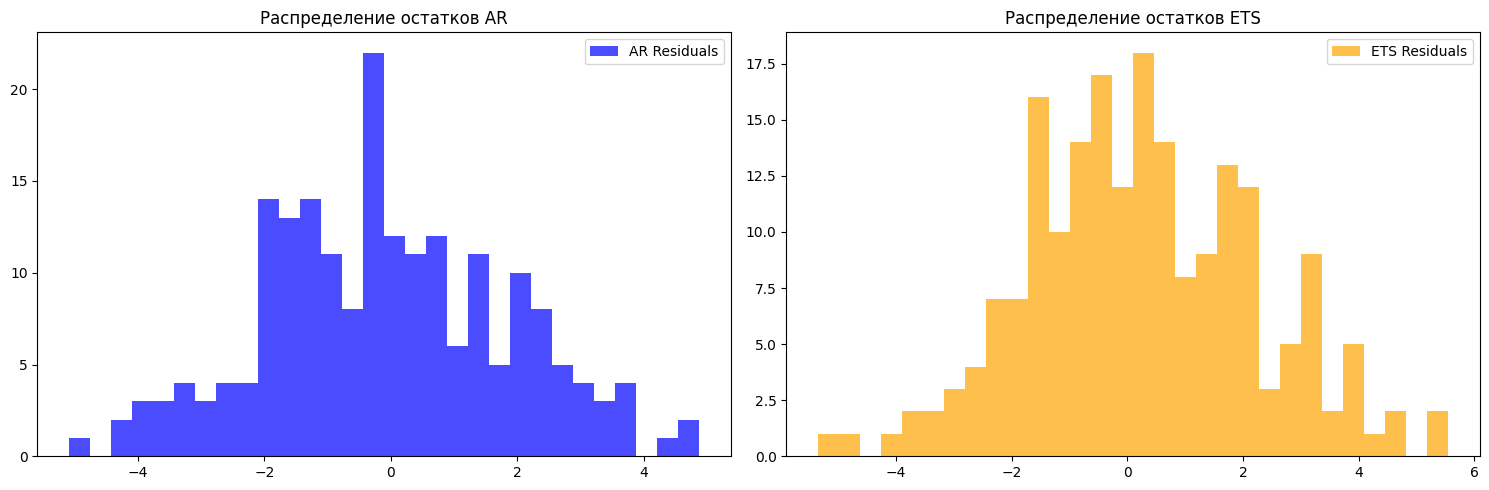

In [7]:
# 1. Сводная таблица метрик
results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'AR': [mean_absolute_error(test['value'], ar_forecast), np.sqrt(mean_squared_error(test['value'], ar_forecast))],
    'ETS': [mean_absolute_error(test['value'], ets_forecast), np.sqrt(mean_squared_error(test['value'], ets_forecast))]
})
display(results.round(3))

# 2. Анализ остатков (Residuals)
ar_residuals = test['value'] - ar_forecast
ets_residuals = test['value'] - ets_forecast

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(ar_residuals, bins=30, alpha=0.7, color='blue', label='AR Residuals')
axes[0].set_title('Распределение остатков AR')
axes[0].legend()

axes[1].hist(ets_residuals, bins=30, alpha=0.7, color='orange', label='ETS Residuals')
axes[1].set_title('Распределение остатков ETS')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Обновленная сводная таблица с Baseline
final_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE'],
    'Naive (Baseline)': [
        mean_absolute_error(test['value'], naive_forecast),
        np.sqrt(mean_squared_error(test['value'], naive_forecast))
    ],
    'AR': [results.loc[0, 'AR'], results.loc[1, 'AR']],
    'ETS': [results.loc[0, 'ETS'], results.loc[1, 'ETS']]
})

print("Сравнение моделей с Baseline:")
display(final_results.round(3))

Сравнение моделей с Baseline:


,Metric,Naive (Baseline),AR,ETS
0,MAE,7.963,1.563,1.574
1,RMSE,9.864,1.935,1.984


## Выводы

### 1. Результаты моделирования
В ходе работы были сопоставлены две классические модели. Обе модели продемонстрировали высокую точность, значительно превосходя базовый сценарий (Naive Forecast):
* **AR (AutoRegression)**: Оказалась наиболее точной для данного ряда (минимальный RMSE). Это объясняется четкой циклической структурой синтетических данных, которую авторегрессия успешно выявила.
* **ETS (Holt-Winters)**: Показала сравнимые результаты, эффективно разделив аддитивный тренд и сезонность.

### 2. Анализ остатков
Распределение остатков близко к нормальному, что указывает на то, что модели извлекли практически всю полезную информацию. Остаточные ошибки представляют собой нескоррелированный шум.
